# Ensemble Learning & Advanced ML Techniques

### Ensemble

In [1]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

X,y=load_wine(return_X_y=True)

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,
    random_state=42)

### Bagging

In [2]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag=BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bag.fit(X_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                  random_state=42)

In [3]:
from sklearn.metrics import accuracy_score

pred=bag.predict(X_test)

print(accuracy_score(y_test,pred))

0.9722222222222222


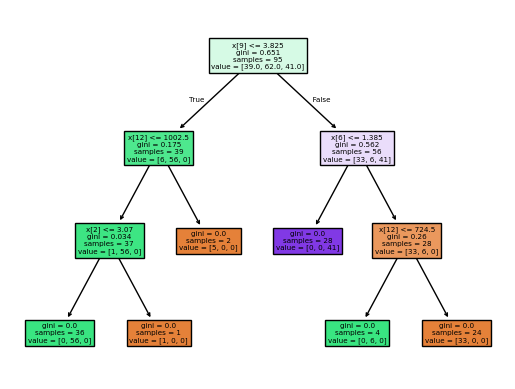

In [4]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plot_tree(
bag.estimators_[0],
filled=True)
plt.show()

### Random Forest

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
n_estimators=200,
max_depth=8,
random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

In [6]:
pred=rf.predict(X_test)

In [7]:
from sklearn.metrics import classification_report

print(classification_report(
y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



<Axes: >

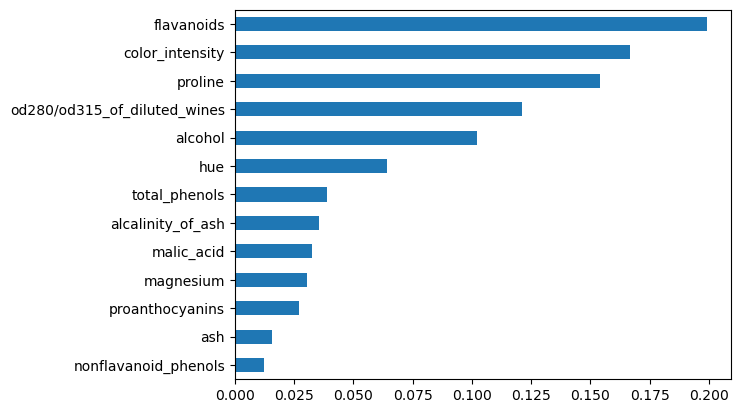

In [8]:
import pandas as pd

importance=pd.Series(
rf.feature_importances_,
index=load_wine().feature_names)

importance.sort_values().plot.barh()

In [9]:
from sklearn.ensemble import ExtraTreesClassifier

model=ExtraTreesClassifier()

model.fit(X_train,y_train)

ExtraTreesClassifier()

### AdaBoost

In [10]:
from sklearn.ensemble import AdaBoostClassifier

ada=AdaBoostClassifier(
n_estimators=100)

ada.fit(X_train,y_train)

c:\Users\parid\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(n_estimators=100)

### Gradient Boosting

In [11]:
from sklearn.ensemble import GradientBoostingClassifier

gb=GradientBoostingClassifier()

gb.fit(X_train,y_train)

GradientBoostingClassifier()

### XGBoost

In [14]:
%pip install xgboost
from xgboost import XGBClassifier

xgb=XGBClassifier(
learning_rate=0.05,
max_depth=6,
n_estimators=300
)

xgb.fit(X_train,y_train)

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   -- ------------------------------------- 3.7/48.9 MB 16.8 MB/s eta 0:00:03
   ----- ---------------------------------- 6.3/48.9 MB 14.3 MB/s eta 0:00:03
   ------- -------------------------------- 8.7/48.9 MB 13.8 MB/s eta 0:00:03
   -------- ------------------------------- 10.2/48.9 MB 13.0 MB/s eta 0:00:03
   ---------- ----------------------------- 12.8/48.9 MB 12.2 MB/s eta 0:00:03
   ------------ --------------------------- 15.2/48.9 MB 12.1 MB/s eta 0:00:03
   -------------- ------------------------- 17.8/48.9 MB 12.1 MB/s eta 0:00:03
   ---------------- ----------------------- 20.4/48.9 MB 12.1 MB/s eta 0:00:03
   ------------------ --------------------- 22.8/48.9 MB 12.1 MB/s eta 0:00:03
   -------------------- ------------------- 25.4/48.9 MB 12.1 MB/s eta 0:00:02
   ---------------------- ----------------- 27.8/48.9 MB 12.1 MB/s eta 0:00:02
   ------------------------ --------------- 30.4/48.9 MB 12.1 MB

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#LightGBM
#%pip install lightgbm
from lightgbm import LGBMClassifier

lgb=LGBMClassifier()

lgb.fit(X_train,y_train)

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 11.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002702 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 509
[LightGBM] [Info] Number of data points in the train set: 142, number of used features: 13
[LightGBM] [Info] Start training from score -1.149165
[LightGBM] [Info] Start training from score -0.912776
[LightGBM] [Info] Start training from score -1.266948
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

LGBMClassifier()

In [ ]:
#CATBOOST

# %pip install catboost
from catboost import CatBoostClassifier

model=CatBoostClassifier(verbose=0)

model.fit(X_train,y_train)

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   - -------------------------------------- 3.4/100.2 MB 15.5 MB/s eta 0:00:07
   -- ------------------------------------- 6.0/100.2 MB 14.2 MB/s eta 0:00:07
   --- ------------------------------------ 8.4/100.2 MB 13.3 MB/s eta 0:00:07
   ---- ----------------------------------- 10.7/100.2 MB 12.9 MB/s eta 0:00:07
   ----- ---------------------------------- 13.4/100.2 MB 12.9 MB/s eta 0:00:07
   ------ --------------------------------- 16.0/100.2 MB 12.7 MB/s eta 0:00:07
   ------- -------------------------------- 18.6/100.2 MB 12.6 MB/s eta 0:00:07
   -------- ------------------------------- 21.0/100.2 MB 12.6 MB/s eta 0:00:07
   --------- ------------------------------ 23.3/100.2 MB 12.5 MB/s eta 0:00:07
   ---------- ----------------------------- 26.0/100.2 MB 12.6 MB/s eta 0:00:06
   ----------- ---------------------------- 28.3/100.2 MB 12.4 MB/s eta 0:00:06
   ------------ --------------------------- 30.9/100

CatBoostClassifier(verbose=0)